# Part 5. Time series forecasting - exercise

> Try your best in one of the Monash datasets!

Today you'll apply the knowledge acquired in part 5 to perform forecasting on one
of the datasets from the Monash time series forecasting archive (TSF). You don't
have to build the TSC algorithm from scratch if you don't want to, but rather make
use of high level tools. Use the ones used in previous exercises such as:
- [aeon](https://github.com/aeon-toolkit/aeon)
- [tsai](https://github.com/timeseriesAI/tsai)
- [tslearn](https://github.com/tslearn-team/tslearn#available-features)
- [sk-time](https://github.com/sktime/sktime)

Or new ones seen in this course:
- [statsmodels](https://www.statsmodels.org/stable/index.html). Implements traditional
statistical forecasting models.
- [pytorch-forecasting](https://pytorch-forecasting.readthedocs.io/en/stable/): Pytorch
library built on top of [pytorch lightning](https://lightning.ai/docs/pytorch/stable/)
that implements several neural forecasting models including NHiTS.

We are going to use the sunspot dataset. This dataset contains a single very long
daily time series of sunspot numbers from 1818-01-08 to 2020-05-31. Be aware that
there is missing data. The nonmissing data version of this dataset was filled with
the LOCV method of imputation.

## Preparing the data

Running the following code is **mandatory**, as it will load the datasets as meant for
the competition.

### Download

In [1]:
import requests
import zipfile
import os
url_train = 'https://zenodo.org/api/records/4654773/files-archive'
url_test = 'https://zenodo.org/api/records/4654722/files-archive'
# Download the zip file

DATA_FOLDER = 'data'
TEMP_FOLDER = 'raw_data'

response = requests.get(url_train)

def get(url):
    response = requests.get(url)
    zip_file_path = os.path.join(TEMP_FOLDER,'temp.zip')  # Specify the path to save the zip file
    with open(zip_file_path, 'wb') as file:
        file.write(response.content)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(TEMP_FOLDER)
    os.remove(zip_file_path)

def extract():
    extracted_zipfile = list(os.listdir(TEMP_FOLDER))[0]
    extracted_zipfile = os.path.join(TEMP_FOLDER, extracted_zipfile)
    with zipfile.ZipFile(extracted_zipfile, 'r') as zip_ref:
        zip_ref.extractall(DATA_FOLDER)
    os.remove(extracted_zipfile)

if not os.path.exists(TEMP_FOLDER):
    os.mkdir(TEMP_FOLDER)
if not os.path.exists('data'):
    os.mkdir(DATA_FOLDER)

get(url_train)
extract()
get(url_test)
extract()

os.rmdir(TEMP_FOLDER)

### Load to memory

In [2]:
# We use the aeon package to load the data. use ``!pip3 install aeon''
from aeon.datasets import load_from_tsf_file

#DATA_FOLDER = 'data' # Specify if the dataset is alread downloaded
TRAIN_DATA_FOLDER = os.path.join(DATA_FOLDER, 'sunspot_dataset_with_missing_values.tsf')
TEST_DATA_FOLDER = os.path.join(DATA_FOLDER, 'sunspot_dataset_without_missing_values.tsf')

missing_data, missing_metadata = load_from_tsf_file(TRAIN_DATA_FOLDER)
nonmissing_data, nonmissing_metadata = load_from_tsf_file(TEST_DATA_FOLDER)

print(missing_metadata)
print(nonmissing_metadata)

{'frequency': 'daily', 'forecast_horizon': None, 'contain_missing_values': True, 'contain_equal_length': True}
{'frequency': 'daily', 'forecast_horizon': None, 'contain_missing_values': False, 'contain_equal_length': True}


### Prepare train and test sets

In [3]:
import datetime
import numpy as np
import pandas as pd

def to_dataframe(dataset):
    numeric_data = np.array(dataset.series_value[0])
    interval_date = datetime.timedelta(days=1) * (len(numeric_data) - 1)
    start_date = dataset.start_timestamp[0]
    date_index = pd.date_range(start_date, interval_date + start_date , freq='D')
    return pd.DataFrame(numeric_data, index=date_index, columns=['sunspot'])

training_data = to_dataframe(missing_data)[:datetime.datetime(2019, 12, 31)]
# The nonmissing data starts from 2020, it si filled with LOCF, some errors are to be expected
TESTING_DATA = to_dataframe(nonmissing_data)[datetime.datetime(2020, 1, 1):]

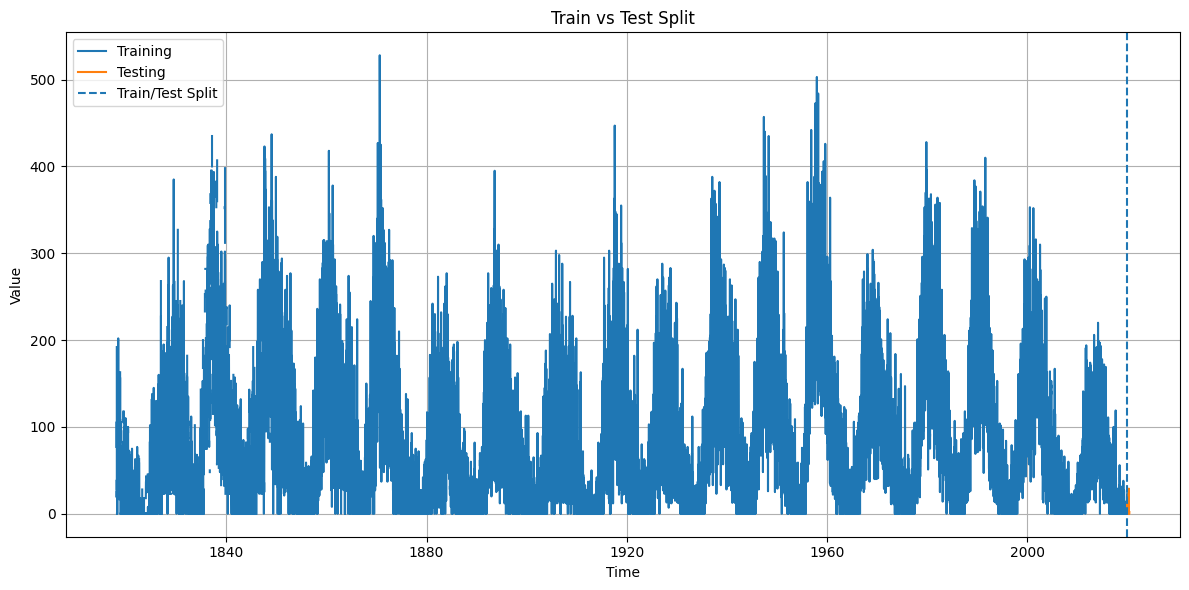

In [4]:
import matplotlib.pyplot as plt

def plot_train_test(training_data, testing_data):
    plt.figure(figsize=(12, 6))

    # Series
    plt.plot(training_data.index, training_data.values, label="Training")
    plt.plot(testing_data.index, testing_data.values, label="Testing")

    # Línea de separación temporal
    split_point = training_data.index[-1]
    plt.axvline(x=split_point, linestyle='--', label="Train/Test Split")

    plt.title("Train vs Test Split")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_train_test(training_data, TESTING_DATA)

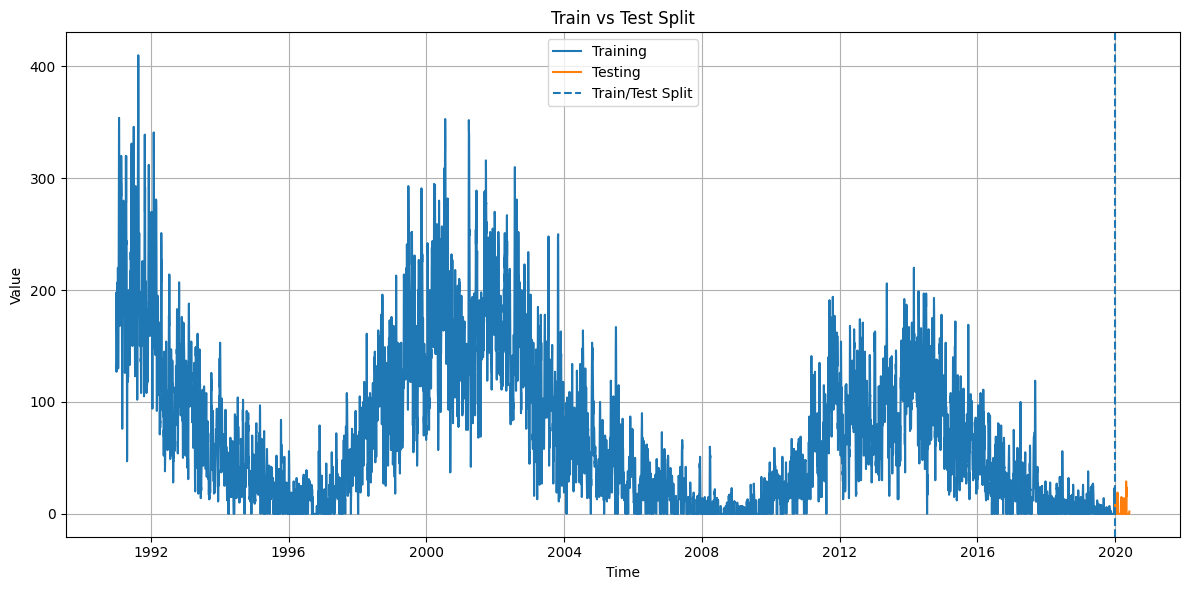

In [5]:
plot_train_test(training_data[datetime.datetime(1990, 12, 31):], TESTING_DATA)
# Parece que hay un patron que se repite cada 10 años aprox

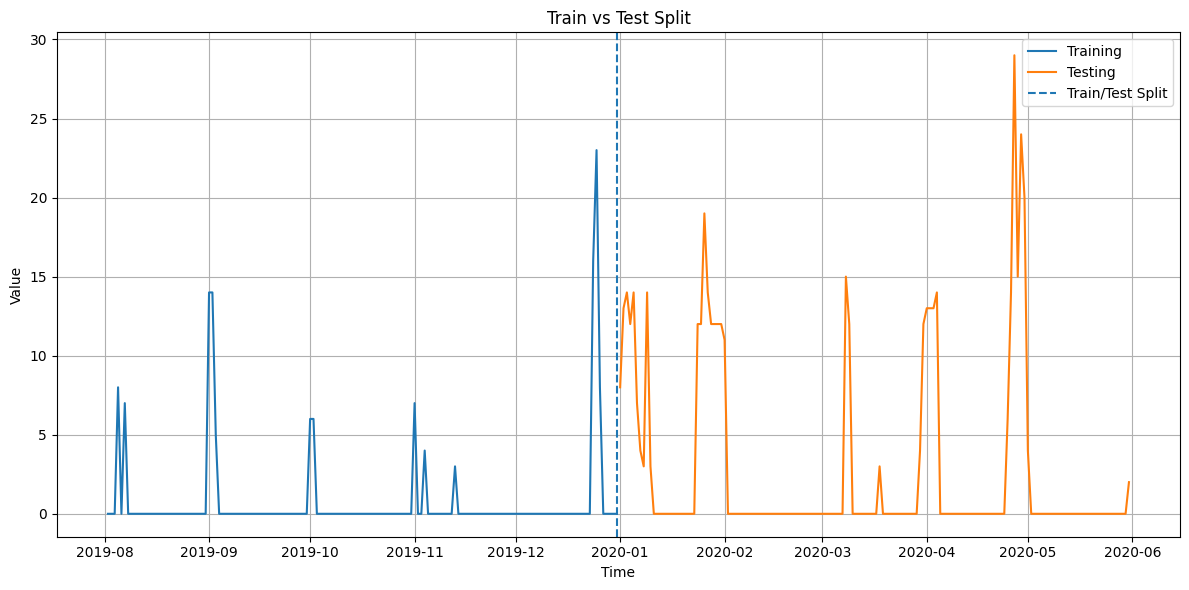

In [6]:
plot_train_test(training_data[-len(TESTING_DATA):], TESTING_DATA)

In [7]:
training_data.head()

,sunspot
1818-01-08,65.0
1818-01-09,NaN
1818-01-10,NaN
1818-01-11,NaN
1818-01-12,NaN


In [8]:
# Convertir la columna 'sunspot' a numérica, forzando los errores a NaN
training_data['sunspot'] = pd.to_numeric(training_data['sunspot'], errors='coerce')

# NAs
print(training_data.isna().sum())

sunspot    3240
dtype: int64


In [9]:
100*(TESTING_DATA.isnull().sum())/len(TESTING_DATA)

sunspot    0.0
dtype: float64

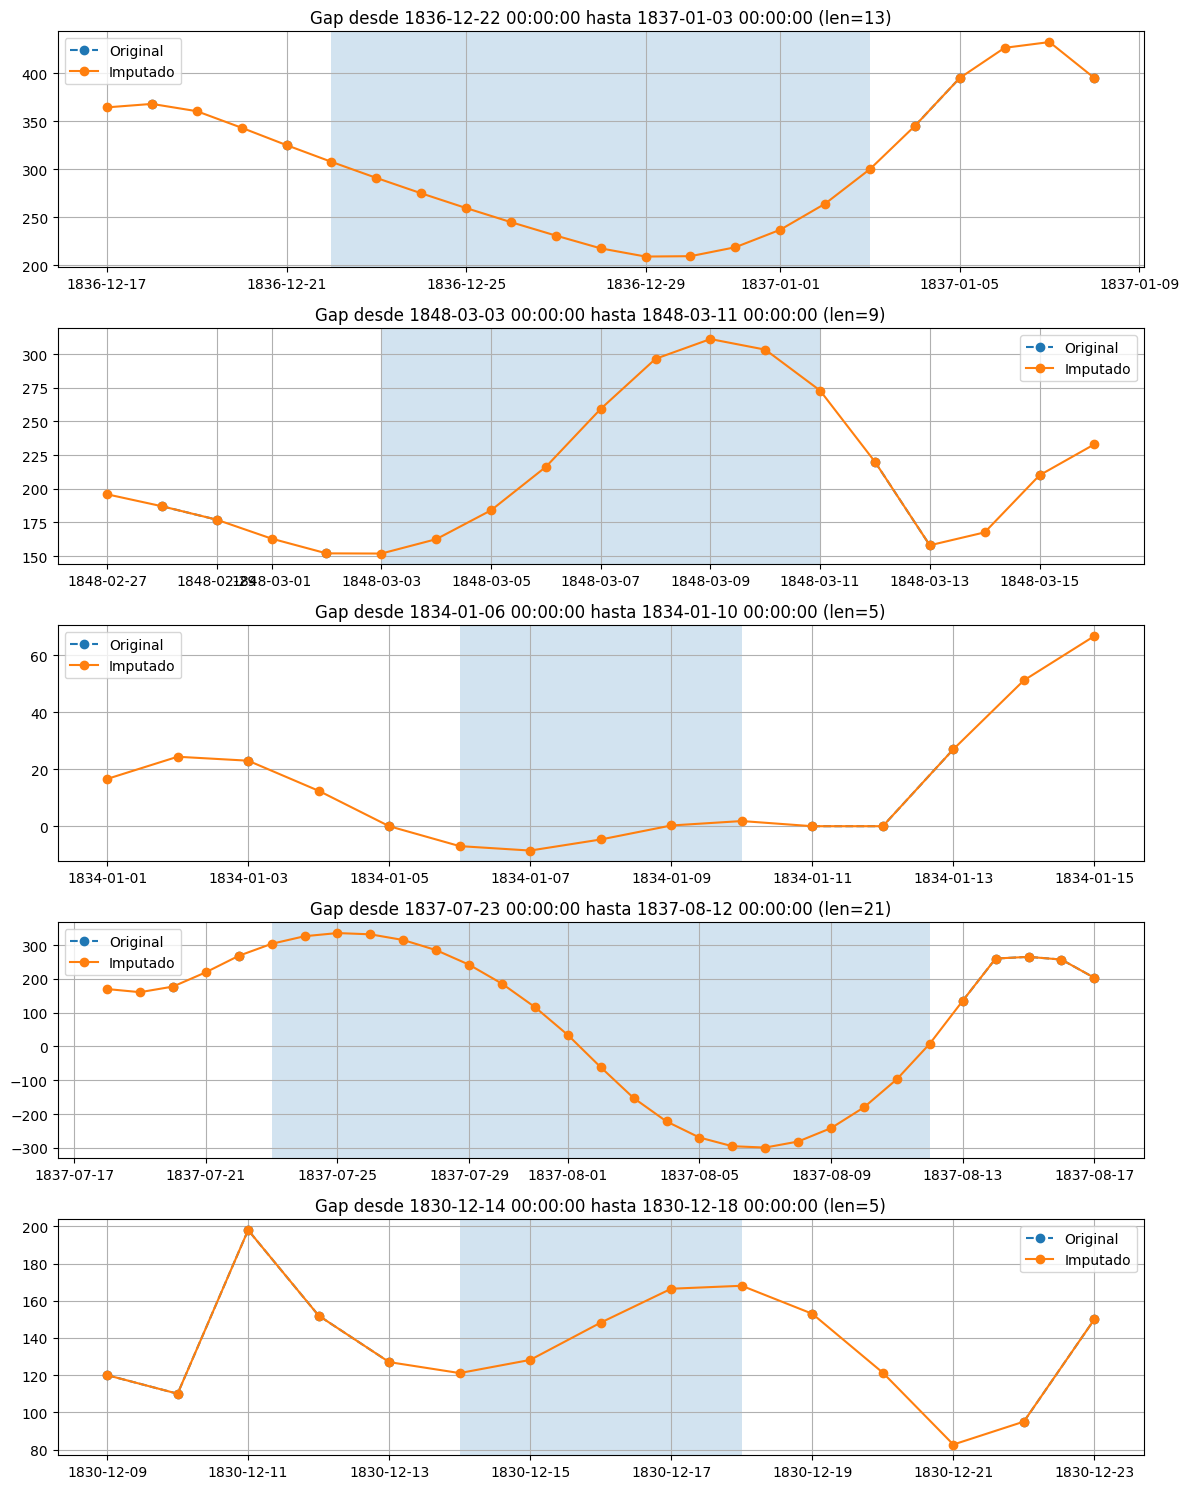

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copia original
original = training_data["sunspot"].copy()

# Imputación
training_data["sunspot"] = training_data["sunspot"].interpolate(method="polynomial", order=2)

# Detectar bloques de NaNs consecutivos
is_nan = original.isna()
groups = (is_nan != is_nan.shift()).cumsum()  # agrupa cambios

gap_blocks = []
for g in groups[is_nan]:
    block_idx = original[groups == g].index
    if len(block_idx) >= 5:
        gap_blocks.append(block_idx)

# Seleccionar hasta 5 gaps aleatorios
selected_gaps = np.random.choice(len(gap_blocks), size=min(5, len(gap_blocks)), replace=False)

# Plot
window = 5  # contexto antes/después
fig, axes = plt.subplots(len(selected_gaps), 1, figsize=(12, 3 * len(selected_gaps)))

if len(selected_gaps) == 1:
    axes = [axes]

for ax, i in zip(axes, selected_gaps):
    gap_idx = gap_blocks[i]

    start_pos = training_data.index.get_loc(gap_idx[0])
    end_pos = training_data.index.get_loc(gap_idx[-1])

    start = max(0, start_pos - window)
    end = min(len(training_data), end_pos + window + 1)

    x = training_data.index[start:end]

    # Original
    ax.plot(x, original.iloc[start:end], linestyle='--', marker='o', label='Original')

    # Imputado
    ax.plot(x, training_data["sunspot"].iloc[start:end], marker='o', label='Imputado')

    # Sombrear el gap
    ax.axvspan(training_data.index[start_pos], training_data.index[end_pos], alpha=0.2)

    ax.set_title(f"Gap desde {gap_idx[0]} hasta {gap_idx[-1]} (len={len(gap_idx)})")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

In [11]:
ts_quarter = training_data.resample("ME").mean()
test_resampled = TESTING_DATA.resample("ME").mean()
TESTING_DATA["sunspot"] = pd.to_numeric(TESTING_DATA['sunspot'], errors='coerce')

# No tenemos NAs
print(TESTING_DATA.isna().sum())

sunspot    0
dtype: int64


In [12]:
print(training_data.isna().sum())

sunspot    0
dtype: int64


# Checks para S/ARIMA

## Autocorrelacion

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

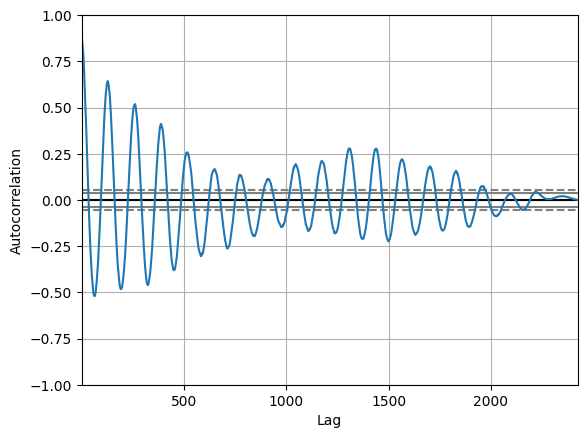

In [13]:
# Autocorrelation?
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(ts_quarter['sunspot'])
# Parece que hay una autocorrelacion de aprox 4_000 lags

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

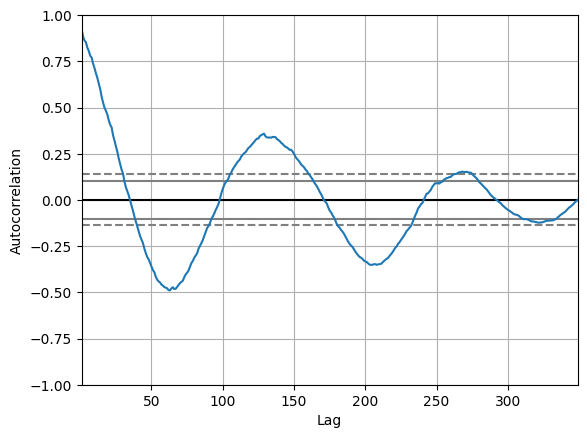

In [14]:
autocorrelation_plot(ts_quarter['sunspot'][datetime.datetime(1990, 12, 31):])

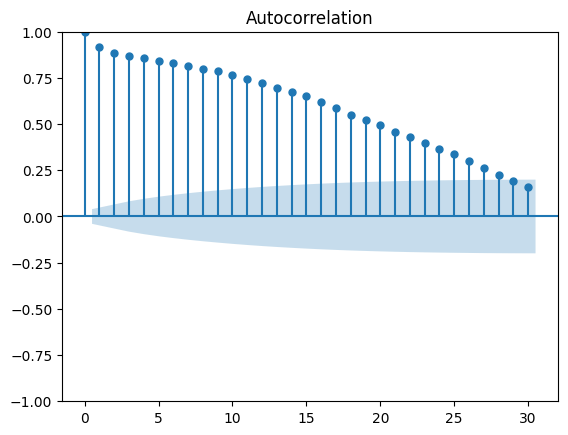

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts_quarter['sunspot'], lags=30)
plt.show()

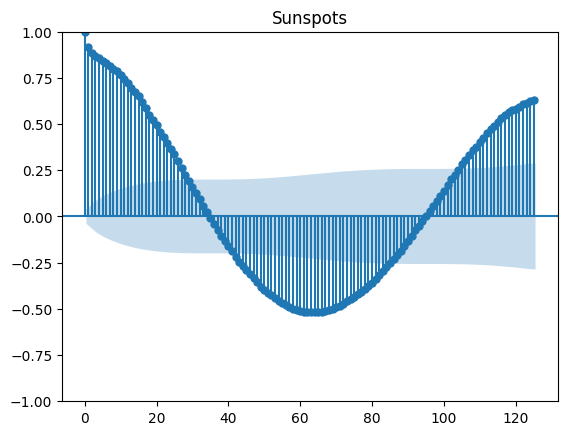

In [16]:
plot_acf(ts_quarter["sunspot"],lags=125,title='Sunspots')
plt.show()

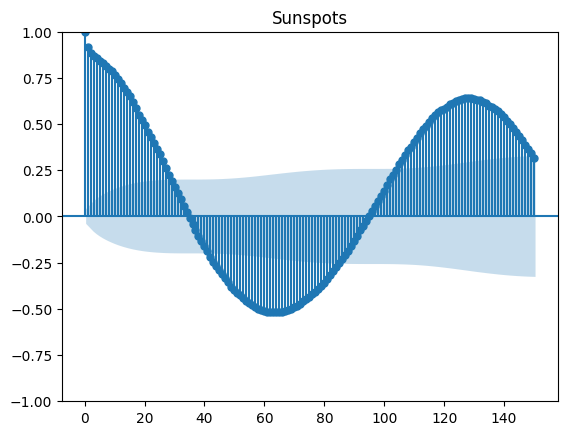

In [17]:
plot_acf(ts_quarter,lags=150,title='Sunspots')
plt.show()

## Autocorrelacion parcial

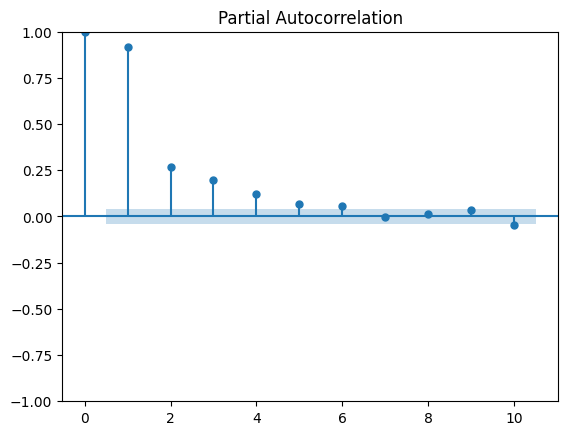

In [18]:
# Partial autocorrelation?
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ts_quarter['sunspot'], lags=10)
plt.show()
# Tenemos un gráfico abrupto con una caida despues del 2o lag

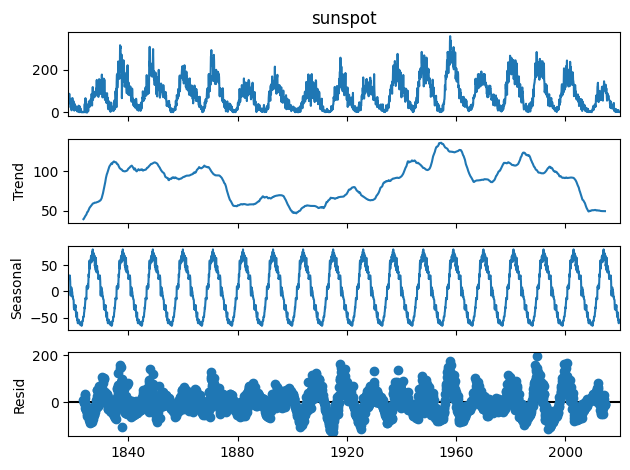

In [19]:
# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(ts_quarter['sunspot'],model='additive',period=11*12)
decomposition.plot()
plt.show()

In [20]:
#Augmented Dickey-Fullert test
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(ts_quarter["sunspot"], autolag = 'AIC')
print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

# P-valor <= 0.05: rechazamos la hipotesis nula. La serie es estacionaria
# Además, ADF es menor que todos los critical values -> Por tanto es estacionaria

1. ADF :  -9.63514282894897
2. P-Value :  1.5738657457524083e-16
3. Num Of Lags :  27
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 2396
5. Critical Values :
	 1% :  -3.433082186844577
	 5% :  -2.8627470426070416
	 10% :  -2.567412559420124


# Task Definition

You have available a training and testing dataset. Both ``training_data`` and ``TESTING_DATA`` are not preprocessed, while training data should be preprocessed, the testing data is to never be modified in any way. The training data contains sunspot information up to (not including) 2020-01-1, while the testing data contains information from 2020-01-1 to 2020-05-31. Your task is to adequately forecast the 2020-05-31. You have to generate a forecast for each day of the testing time series. The objective metric to minimize is *RMSE*.

> Good luck!


## Your implementation

### Optuna

In [21]:
import optuna
from sklearn.metrics import mean_squared_error

def objective(trial, trainset, testset, model_builder):
    try:
        model = model_builder(trial, trainset)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(testset))

        # Asegurar formato consistente (numpy arrays)
        y_true = np.asarray(testset).flatten()
        y_pred = np.asarray(forecast).flatten()

        # Validación básica (evita errores silenciosos)
        if len(y_true) != len(y_pred):
            raise optuna.exceptions.TrialPruned()

        if np.any(np.isnan(y_pred)):
            raise optuna.exceptions.TrialPruned()

        rmse = mean_squared_error(y_true, y_pred)

        return rmse

    except (ValueError, np.linalg.LinAlgError):
        raise optuna.exceptions.TrialPruned()

/home/adrian/git_repos/ejercicios-series-temporales/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
def rebuild_model(frozen_trial, trainset, model_builder):
    """
    Reconstruye un modelo usando los parámetros de un trial de Optuna completado.

    Parámetros:
    frozen_trial: El trial completado de Optuna (ej. study.best_trial)
    trainset: Los datos de entrenamiento.
    model_builder: La función que construye el modelo (ej. arima_builder).
    """
    # 1. Extraemos los parámetros del trial completado y creamos un FixedTrial
    fixed_trial = optuna.trial.FixedTrial(frozen_trial.params)

    # 2. Pasamos el FixedTrial a tu función constructora original
    model = model_builder(fixed_trial, trainset)

    return model

### Evaluator

In [23]:
import matplotlib.pyplot as plt

def evaluate_forecast(testset, forecast):
    """
    Evalúa cualitativa y cuantitativamente un pronóstico de series temporales.
    Maneja DataFrames, Series y arrays de numpy.
    """
    # 1. Asegurar alineación y formato (Conversión robusta)
    # Si es DataFrame, extraemos la primera columna como valores
    if isinstance(testset, pd.DataFrame):
        y_true = testset.iloc[:, 0].values
        index = testset.index
    elif isinstance(testset, pd.Series):
        y_true = testset.values
        index = testset.index
    else:
        y_true = np.array(testset)
        index = np.arange(len(y_true))

    # Lo mismo para el forecast
    if isinstance(forecast, pd.DataFrame):
        y_pred = forecast.iloc[:, 0].values
    elif isinstance(forecast, pd.Series):
        y_pred = forecast.values
    else:
        y_pred = np.array(forecast)

    # Forzar que ambos sean vectores planos (1D) del mismo tamaño
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    residuos = y_pred - y_true

    # 2. Evaluación Cuantitativa (Métricas)
    mae = np.mean(np.abs(residuos))
    rmse = np.sqrt(np.mean(residuos**2))
    
    # MAPE seguro (evitando división por cero)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs(residuos / y_true)) * 100
        if np.isinf(mape) or np.isnan(mape):
            mape_str = "Indefinido (ceros en testset)"
        else:
            mape_str = f"{mape:.2f} %"

    print("-" * 30)
    print("MÉTRICAS DE EVALUACIÓN")
    print("-" * 30)
    print(f"MAE  (Error Absoluto Medio): {mae:.4f}")
    print(f"RMSE (Raíz Error Cuadrático): {rmse:.4f}")
    print(f"MAPE (Error Porcentual):      {mape_str}")
    print("-" * 30)

    # 3. Evaluación Cualitativa (Plots)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análisis de Calidad del Forecast', fontsize=16)

    # PLOT 1: Real vs Predicho
    ax1 = axes[0, 0]
    ax1.plot(index, y_true, label='Real (Testset)', color='#1f77b4', alpha=0.8)
    ax1.plot(index, y_pred, label='Predicción', color='#ff7f0e', linestyle='--')
    ax1.set_title('Predicción vs Valores Reales')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # PLOT 2: Residuos
    ax2 = axes[0, 1]
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(index, residuos, color='#d62728', alpha=0.6)
    ax2.set_title('Residuos (Errores) en el tiempo')
    ax2.grid(alpha=0.3)

    # PLOT 3: Histograma
    ax3 = axes[1, 0]
    ax3.hist(residuos, bins=20, edgecolor='black', color='#9467bd', alpha=0.7)
    ax3.axvline(0, color='black', linestyle='--')
    ax3.set_title('Distribución de los Residuos')
    ax3.grid(alpha=0.3)

    # PLOT 4: Scatter Plot
    ax4 = axes[1, 1]
    ax4.scatter(y_true, y_pred, alpha=0.5, color='#2ca02c')
    lims = [np.min([y_true, y_pred]), np.max([y_true, y_pred])]
    ax4.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
    ax4.set_title('Dispersión: Predicción vs Realidad')
    ax4.set_xlabel('Real')
    ax4.set_ylabel('Predicción')
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    fig.subplots_adjust(top=0.9)
    plt.show()

## ARIMA/SARIMA

In [24]:
from statsmodels.tsa.arima.model import ARIMA
import optuna
def arima_builder(trial, trainset):
    n = len(trainset)

    # Rango adaptativo: evita explorar órdenes demasiado grandes en series cortas
    max_pq = max(1, min(5, n // 20))
    max_d = 2

    p = trial.suggest_int("p", 0, max_pq)
    d = trial.suggest_int("d", 0, max_d)
    q = trial.suggest_int("q", 0, max_pq)

    # Decidir si el modelo tendrá estacionalidad o no
    use_seasonal = trial.suggest_categorical("use_seasonal", [False, True])

    if use_seasonal:
        s = trial.suggest_categorical("s", [4, 7, 12])
        P = trial.suggest_int("P", 0, 2)
        D = trial.suggest_int("D", 0, 1)
        Q = trial.suggest_int("Q", 0, 2)
        seasonal_order = (P, D, Q, s)
    else:
        seasonal_order = (0, 0, 0, 0)

    # Trend opcional. "n" suele ser la opción más estable.
    trend = trial.suggest_categorical("trend", ["n", "c"])

    try:
        model = ARIMA(
            trainset,
            order=(p, d, q),
            seasonal_order=seasonal_order,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        return model
    except Exception:
        raise optuna.exceptions.TrialPruned()

## Valores de ARIMA basado en lo visto por los gráficos
- S = 43 porque en el plot ACF, ese era el lag en el que teníamos el primer pico alto
- p = 3 porque es primer lag en el PACF que entrá dentro del area significativa
- q = 10 porque es el primer lag donde el valor está por encima del nivel de significacia

- D = 1 porque tiene un patron seasonal estable
- P = 1 porque ACF es positivo en el lag 43 y es necesario que P+Q<=2
- Q = 0 porque ACF es negativo en el lag 43 y P + Q <=2

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(ts_quarter, trend='n', order=(7,0,4), seasonal_order=(1,1,0,10))
results = model.fit()
print(results.summary())

/home/adrian/git_repos/ejercicios-series-temporales/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adrian/git_repos/ejercicios-series-temporales/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adrian/git_repos/ejercicios-series-temporales/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                             sunspot   No. Observations:                 2424
Model:             SARIMAX(7, 0, 4)x(1, 1, [], 10)   Log Likelihood              -11541.727
Date:                             Thu, 26 Mar 2026   AIC                          23109.455
Time:                                     17:35:03   BIC                          23184.712
Sample:                                 01-31-1818   HQIC                         23136.826
                                      - 12-31-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5672      0.020     27.925      0.000       0.527       0.607
ar.L2          0.6517      

In [30]:

final_forecast = results.predict(len(test_resampled))



In [77]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Generar la predicción alineada con el periodo de TESTING_DATA
# Usamos los índices de TESTING_DATA para decirle al modelo exactamente qué predecir
start_index = TESTING_DATA.index.min()
end_index = TESTING_DATA.index.max()

# statsmodels permite usar etiquetas de fecha si el índice del modelo es Datetime
# Generamos el forecast directamente en el rango necesario
final_forecast = results.predict(start=start_index, end=end_index)

# 2. Asegurar DatetimeIndex y limpieza de zonas horarias
final_forecast.index = pd.to_datetime(final_forecast.index).tz_localize(None)
TESTING_DATA.index = pd.to_datetime(TESTING_DATA.index).tz_localize(None)

# 3. Upsampling a frecuencia diaria e interpolación
# (Ahora final_forecast ya tiene el rango de 2020-01-01 a 2020-05-31)
forecast_daily = final_forecast.resample('D').asfreq()
forecast_daily_interp = forecast_daily.interpolate(method='polynomial', order=2)

# Rellenar posibles NaNs en los bordes por la interpolación
forecast_daily_interp = forecast_daily_interp.bfill().ffill()

# 4. Alineación mediante concatenación (Join Inner)
# Esto asegura que solo comparamos días que existen en ambos
df_eval = pd.concat([TESTING_DATA, forecast_daily_interp], axis=1, join='inner').dropna()

# Renombrar columnas para claridad
df_eval.columns = ['y_true', 'y_pred']

# 5. Cálculo del RMSE
if not df_eval.empty:
    rmse = np.sqrt(mean_squared_error(df_eval['y_true'], df_eval['y_pred']))
    print(f"Días comparados: {len(df_eval)}")
    print(f"RMSE (Interpolado Diario): {rmse}")
else:
    print("Error: El DataFrame de evaluación sigue vacío. Revisa la frecuencia de los índices.")

Días comparados: 122
RMSE (Interpolado Diario): 7.673693880372536


------------------------------
MÉTRICAS DE EVALUACIÓN
------------------------------
MAE  (Error Absoluto Medio): 5.9750
RMSE (Raíz Error Cuadrático): 7.6737
MAPE (Error Porcentual):      Indefinido (ceros en testset)
------------------------------


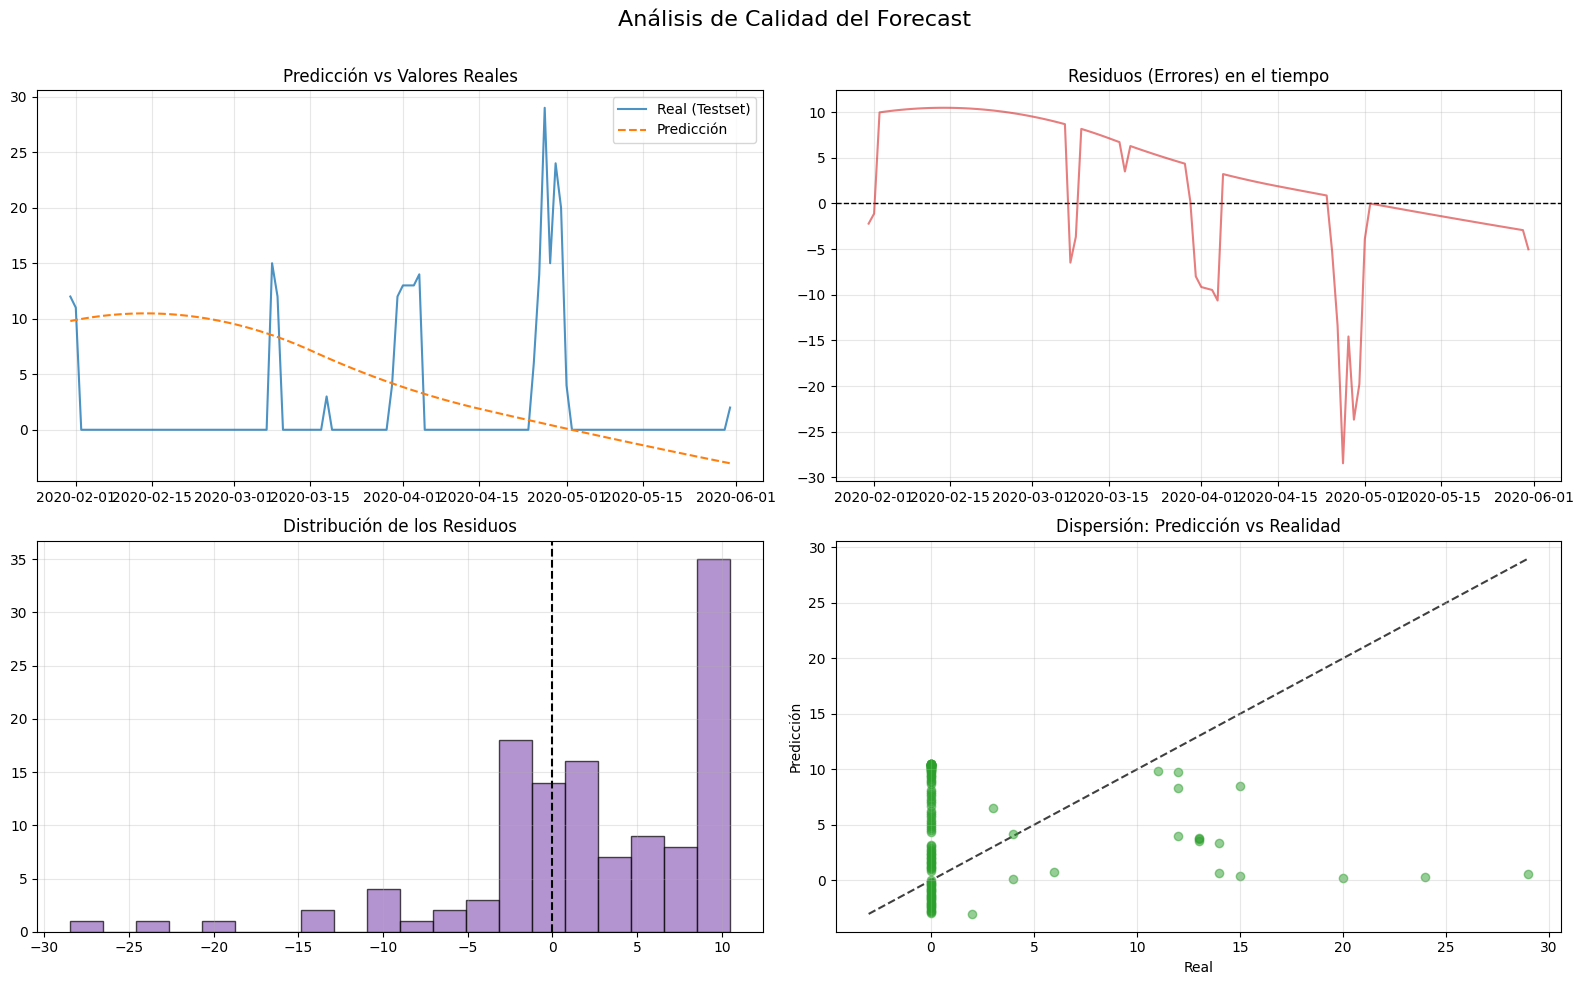

In [78]:
evaluate_forecast(df_eval['y_true'], df_eval['y_pred'])